# Data Cleaning in Pandas: A Demo Using the Titanic Dataset
This notebook introduces the basics of **data cleaning** in Pandas using the Titanic dataset. We’ll cover how to identify and handle missing data, remove duplicates, fix data types, and tidy up column names.

---

## 1. Load the Titanic Dataset

In [1]:

import pandas as pd
import seaborn as sns

# Load Titanic dataset from seaborn
df = sns.load_dataset('titanic')
df.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 2. Explore the Data
Let's inspect the structure and summary statistics of the dataset.

In [2]:
# Shape and basic info
df.shape

(891, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [4]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# Basic statistics
df.describe(include='all')

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
sibsp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292
embarked,889,3,S,644,NaN,NaN,NaN,NaN,NaN,NaN,NaN
class,891,3,Third,491,NaN,NaN,NaN,NaN,NaN,NaN,NaN
who,891,3,man,537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Identifying Missing Data
Missing data is one of the most common issues in real-world datasets.

In [7]:
# Count missing values per column
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [8]:
df.isnull()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
887,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False
889,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


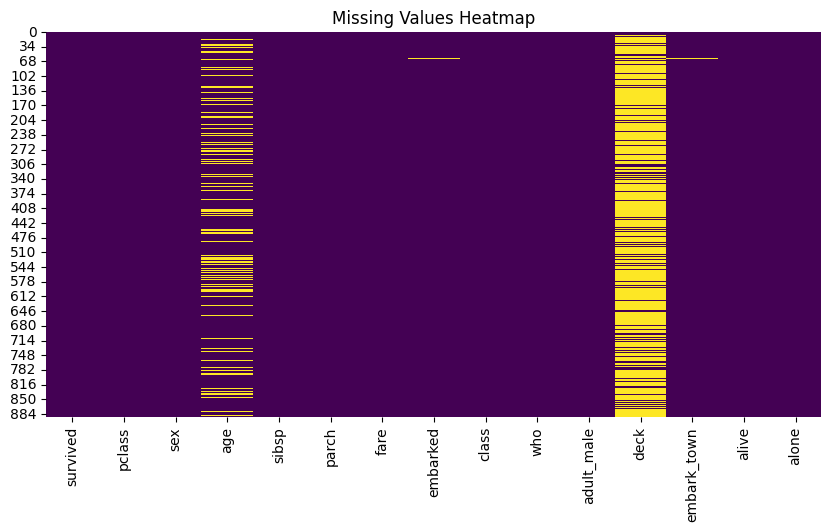

In [9]:
# Visual summary of missing data
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

## 4. Handling Missing Data
We can either **drop** missing data or **fill** it using an appropriate strategy.

In [10]:
# Drop rows where 'embarked' is missing
df = df.dropna(subset=['embarked'])

In [11]:
df.shape

(889, 15)

In [12]:
# Fill missing 'age' values with median
df['age'] = df['age'].fillna(df['age'].median())

In [13]:
df['age'].median()

28.0

In [14]:
df['age']

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
...,...
886,27.0
887,19.0
888,28.0
889,26.0


In [15]:
# Fill missing 'deck' values with a placeholder
df['deck'] = df['deck'].cat.add_categories('Unknown')
df['deck'] = df['deck'].fillna('Unknown')

In [16]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,Unknown,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,28.0,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [17]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


## 5. Detecting and Removing Duplicates

In [18]:
# Check for duplicates
duplicates = df.duplicated().sum()
#
print("Number of duplicate rows: "+str(duplicates))

Number of duplicate rows: 110


In [19]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
886,True
887,False
888,False
889,False


In [20]:
# Show duplicates
df[df.duplicated()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
47,1,3,female,28.0,0,0,7.7500,Q,Third,woman,False,Unknown,Queenstown,yes,True
76,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
77,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
87,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
95,0,3,male,28.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
870,0,3,male,26.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
877,0,3,male,19.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
878,0,3,male,28.0,0,0,7.8958,S,Third,man,True,Unknown,Southampton,no,True
884,0,3,male,25.0,0,0,7.0500,S,Third,man,True,Unknown,Southampton,no,True


In [21]:
# Remove duplicates
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (779, 15)


## 6. Fixing Data Types
Sometimes numeric columns are read as objects or categorical values aren’t properly set.

In [22]:
# Example: ensure 'pclass' is categorical
df['pclass'] = df['pclass'].astype('category')

/tmp/ipykernel_470/3962488546.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pclass'] = df['pclass'].astype('category')


In [23]:
# Convert 'survived' to boolean
df['survived'] = df['survived'].astype(bool)

/tmp/ipykernel_470/1243101974.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['survived'] = df['survived'].astype(bool)


In [24]:
df.dtypes

,0
survived,bool
pclass,category
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
class,category
who,object


## 7. Renaming Columns
Let's make the column names clearer and more consistent.

In [25]:
#doesn't change df
df.rename(columns={
    'sibsp': 'siblings_spouses_aboard',
    'parch': 'parents_children_aboard'
})

,survived,pclass,sex,age,siblings_spouses_aboard,parents_children_aboard,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,True,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,True,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,True,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,False,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,False,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Unknown,Queenstown,no,False
887,True,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,False,3,female,28.0,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
889,True,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [26]:
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,True,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,True,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,True,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,False,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,False,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Unknown,Queenstown,no,False
887,True,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,False,3,female,28.0,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
889,True,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [27]:
#does change df
df = df.rename(columns={
    'sibsp': 'siblings_spouses_aboard',
    'parch': 'parents_children_aboard'
})

In [28]:
df

,survived,pclass,sex,age,siblings_spouses_aboard,parents_children_aboard,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,False,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,True,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,True,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,True,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,False,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
885,False,3,female,39.0,0,5,29.1250,Q,Third,woman,False,Unknown,Queenstown,no,False
887,True,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,False,3,female,28.0,1,2,23.4500,S,Third,woman,False,Unknown,Southampton,no,False
889,True,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True
